# 01 EDA and Features

## P1 · Time-Series EDA

This section is P1 only. It reads the P0 panel artifact, profiles the time series, and writes P1 tables/figures. It does not build features, train forecasting models, or inspect supporting exogenous relationships beyond store metadata needed to define hierarchy levels.

In [1]:
from pathlib import Path
import os
import warnings

import matplotlib
import numpy as np
import pandas as pd
from IPython.display import Image, display
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf
%matplotlib inline
warnings.filterwarnings("ignore")

CWD = Path.cwd().resolve()
if (CWD / "data" / "interim" / "panel.parquet").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "data" / "interim" / "panel.parquet").exists():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError(
        "Run this notebook from the repo root or notebooks/ after P0 builds data/interim/panel.parquet"
    )

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "outputs" / ".matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt

PANEL_PATH = PROJECT_ROOT / "data" / "interim" / "panel.parquet"
STORES_PATH = PROJECT_ROOT / "data" / "raw" / "favorita" / "stores.csv"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "p1_ts_eda"
TABLE_DIR = PROJECT_ROOT / "outputs" / "metrics" / "p1_ts_eda"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")

### Helper Functions

Notebook helpers are kept top-level and pandas-first. No nested functions are used.

In [2]:
def save_and_show(fig: plt.Figure, path: Path) -> None:
    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches="tight")
    display_saved_image(path)
    plt.close(fig)


def display_saved_image(path: Path) -> None:
    display(Image(filename=str(path)))


def demand_segment(adi: float, cv2: float) -> str:
    if adi < 1.32 and cv2 < 0.49:
        return "smooth"
    if adi < 1.32 and cv2 >= 0.49:
        return "erratic"
    if adi >= 1.32 and cv2 < 0.49:
        return "intermittent"
    return "lumpy"


def lag_autocorrelation(values: pd.Series, lag: int) -> float:
    clean = values.astype(float).to_numpy()
    if len(clean) <= lag:
        return np.nan
    left = clean[:-lag]
    right = clean[lag:]
    if np.std(left) == 0 or np.std(right) == 0:
        return np.nan
    return float(np.corrcoef(left, right)[0, 1])


def stationarity_result(name: str, values: pd.Series) -> dict:
    clean = values.astype(float).dropna()
    diffed = clean.diff().dropna()
    return {
        "series": name,
        "adf_p": adfuller(clean, autolag="AIC")[1],
        "kpss_p": kpss(clean, regression="c", nlags="auto")[1],
        "diff_adf_p": adfuller(diffed, autolag="AIC")[1],
        "diff_kpss_p": kpss(diffed, regression="c", nlags="auto")[1],
    }


def hierarchy_daily(frame: pd.DataFrame, keys: list, name: str) -> pd.DataFrame:
    if keys:
        grouped = frame.groupby(keys + ["date"], observed=True, as_index=False)["sales"].sum()
        grouped["level"] = name
        grouped["series_id"] = grouped[keys].astype(str).agg("|".join, axis=1)
        return grouped[["level", "series_id", "date", "sales"]]
    grouped = frame.groupby("date", as_index=False)["sales"].sum()
    grouped["level"] = name
    grouped["series_id"] = "total"
    return grouped[["level", "series_id", "date", "sales"]]


def zero_rate_summary(frame: pd.DataFrame, keys: list, name: str) -> dict:
    daily = hierarchy_daily(frame, keys, name)
    return {
        "level": name,
        "series_count": daily["series_id"].nunique(),
        "rows": len(daily),
        "zero_rate": float((daily["sales"] == 0).mean()),
        "mean_daily_sales": float(daily["sales"].mean()),
    }


def stationarity_sample(frame: pd.DataFrame, limit: int) -> pd.DataFrame:
    totals = frame.groupby("series_id", observed=True)["sales"].sum().sort_values(ascending=False)
    rows = []
    for series_id in totals.head(limit).index:
        values = frame.loc[frame["series_id"] == series_id].sort_values("date").set_index("date")["sales"].asfreq("D").fillna(0)
        rows.append(stationarity_result(str(series_id), values))
    return pd.DataFrame(rows)


def acf_table(name: str, values: pd.Series, nlags: int) -> pd.DataFrame:
    acf_values = acf(values, nlags=nlags, fft=True)
    pacf_values = pacf(values, nlags=nlags, method="ywm")
    rows = []
    for lag, value in enumerate(acf_values):
        rows.append({"series": name, "kind": "acf", "lag": lag, "value": value})
    for lag, value in enumerate(pacf_values):
        rows.append({"series": name, "kind": "pacf", "lag": lag, "value": value})
    return pd.DataFrame(rows)


def plot_acf_pacf(name: str, values: pd.Series, nlags: int, path: Path) -> pd.DataFrame:
    table = acf_table(name, values, nlags)
    acf_values = table.loc[table["kind"] == "acf", "value"].to_numpy()
    pacf_values = table.loc[table["kind"] == "pacf", "value"].to_numpy()
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    axes[0].bar(range(len(acf_values)), acf_values)
    axes[0].set_title(f"{name} ACF")
    axes[1].bar(range(len(pacf_values)), pacf_values)
    axes[1].set_title(f"{name} PACF")
    axes[1].set_xlabel("Lag")
    save_and_show(fig, path)
    return table

### Load P0 Panel

The notebook starts from the P0 artifact required by the constitution.

In [3]:
panel = pd.read_parquet(PANEL_PATH)
stores = pd.read_csv(STORES_PATH)
panel["date"] = pd.to_datetime(panel["date"])
joined = panel.merge(stores, on="store_nbr", how="left")

panel_summary = pd.DataFrame(
    {
        "rows": [len(panel)],
        "min_date": [panel["date"].min().date()],
        "max_date": [panel["date"].max().date()],
        "bottom_series": [panel[["store_nbr", "family"]].drop_duplicates().shape[0]],
    }
)
panel_summary.to_csv(TABLE_DIR / "panel_summary.csv", index=False)
panel_summary

,rows,min_date,max_date,bottom_series
0,2450500,2013-01-01,2017-08-15,1729


### Figure Gallery

These images are generated by the P1 cells below and embedded here so the notebook has visible plots when opened after execution.

![Total daily sales](../outputs/figures/p1_ts_eda/total_daily_sales.png)

![Total weekly sales](../outputs/figures/p1_ts_eda/total_weekly_sales.png)

![Intermittency segment counts](../outputs/figures/p1_ts_eda/intermittency_segment_counts.png)

![Zero rate by level](../outputs/figures/p1_ts_eda/zero_rate_by_level.png)

![Daily STL decomposition](../outputs/figures/p1_ts_eda/daily_total_stl.png)

![Weekly STL decomposition](../outputs/figures/p1_ts_eda/weekly_total_stl.png)

![Daily ACF PACF](../outputs/figures/p1_ts_eda/daily_total_acf_pacf.png)

![Weekly ACF PACF](../outputs/figures/p1_ts_eda/weekly_total_acf_pacf.png)

![Bottom zero-rate distribution](../outputs/figures/p1_ts_eda/bottom_zero_rate_distribution.png)

### Series Inventory and Intermittency

Inventory covers active post-P0 bottom series, launch date, available history length, zero rate, and inactive final-period series.

In [4]:
bottom_groups = panel.groupby(["store_nbr", "family"], observed=True)
series_inventory = bottom_groups.agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    n_days=("date", "size"),
    zero_rate=("sales", lambda values: float((values == 0).mean())),
    total_sales=("sales", "sum"),
    positive_days=("sales", lambda values: int((values > 0).sum())),
).reset_index()
positive = panel.loc[panel["sales"] > 0].groupby(["store_nbr", "family"], observed=True)["sales"]
positive_stats = positive.agg(positive_mean="mean", positive_std="std").reset_index()
series_inventory = series_inventory.merge(positive_stats, on=["store_nbr", "family"], how="left")
series_inventory["adi"] = series_inventory["n_days"] / series_inventory["positive_days"]
series_inventory["cv2"] = (series_inventory["positive_std"] / series_inventory["positive_mean"]) ** 2
series_inventory["cv2"] = series_inventory["cv2"].fillna(0)
series_inventory["intermittency_segment"] = [
    demand_segment(adi, cv2) for adi, cv2 in zip(series_inventory["adi"], series_inventory["cv2"])
]
last_date = panel["date"].max()
recent = (
    panel.loc[panel["date"] > last_date - pd.Timedelta(days=90)]
    .groupby(["store_nbr", "family"], observed=True)["sales"]
    .sum()
    .rename("last_90_sales")
    .reset_index()
)
series_inventory = series_inventory.merge(recent, on=["store_nbr", "family"], how="left")
series_inventory["dead_last_90_days"] = series_inventory["last_90_sales"].fillna(0).eq(0)
series_inventory.to_csv(TABLE_DIR / "series_inventory.csv", index=False)

inventory_summary = pd.DataFrame(
    {
        "active_series": [len(series_inventory)],
        "min_days": [series_inventory["n_days"].min()],
        "median_days": [series_inventory["n_days"].median()],
        "max_days": [series_inventory["n_days"].max()],
        "mean_zero_rate": [series_inventory["zero_rate"].mean()],
        "dead_last_90_days": [int(series_inventory["dead_last_90_days"].sum())],
    }
)
inventory_summary.to_csv(TABLE_DIR / "inventory_summary.csv", index=False)
inventory_summary

,active_series,min_days,median_days,max_days,mean_zero_rate,dead_last_90_days
0,1729,37,1686.0,1688,0.181381,31


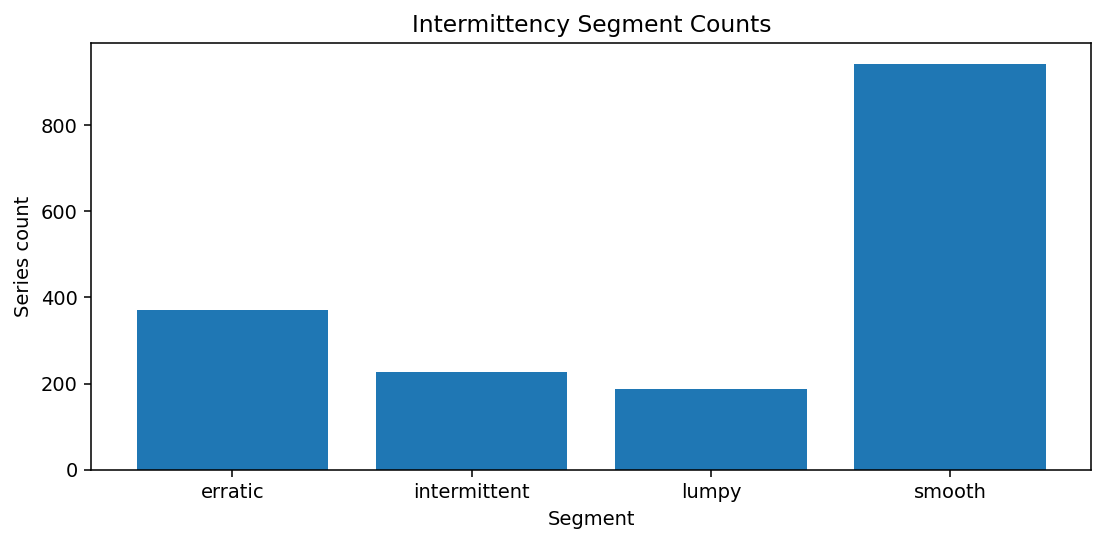

In [5]:
intermittency_counts = (
    series_inventory.groupby("intermittency_segment", observed=True)
    .size()
    .rename("series_count")
    .reset_index()
    .sort_values("intermittency_segment")
)
intermittency_counts.to_csv(TABLE_DIR / "intermittency_segments.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(intermittency_counts["intermittency_segment"], intermittency_counts["series_count"])
ax.set_title("Intermittency Segment Counts")
ax.set_xlabel("Segment")
ax.set_ylabel("Series count")
save_and_show(fig, FIGURE_DIR / "intermittency_segment_counts.png")
#intermittency_counts
plt.show()

### Zero Rate by Hierarchy Level

This checks the constitution's model-to-level assumption that upper levels are dense while bottom store-family series are intermittent.

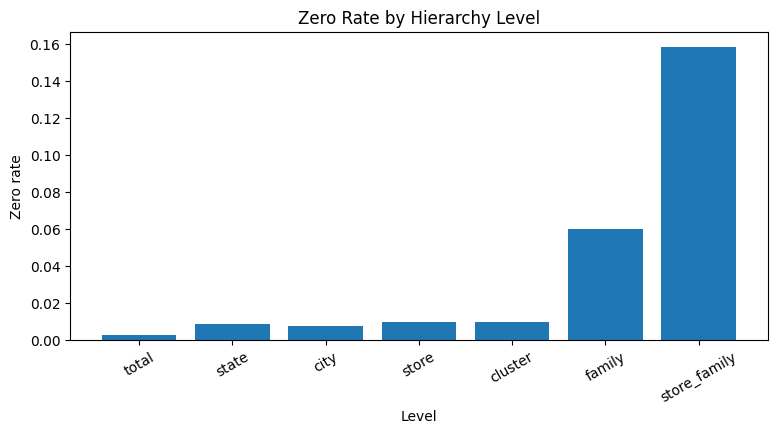

In [6]:
level_specs = [
    ([], "total"),
    (["state"], "state"),
    (["city"], "city"),
    (["store_nbr"], "store"),
    (["cluster"], "cluster"),
    (["family"], "family"),
    (["store_nbr", "family"], "store_family"),
]
zero_rate_by_level = pd.DataFrame([zero_rate_summary(joined, keys, name) for keys, name in level_specs])
zero_rate_by_level.to_csv(TABLE_DIR / "zero_rate_by_level.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(zero_rate_by_level["level"], zero_rate_by_level["zero_rate"])
ax.set_title("Zero Rate by Hierarchy Level")
ax.set_xlabel("Level")
ax.set_ylabel("Zero rate")
ax.tick_params(axis="x", rotation=30)
#save_and_show(fig, FIGURE_DIR / "zero_rate_by_level.png")
zero_rate_by_level
plt.show()

### Total Series Shape and Decomposition

Daily and weekly total series show trend, weekly/annual structure, and whether weekly grain is defensible.

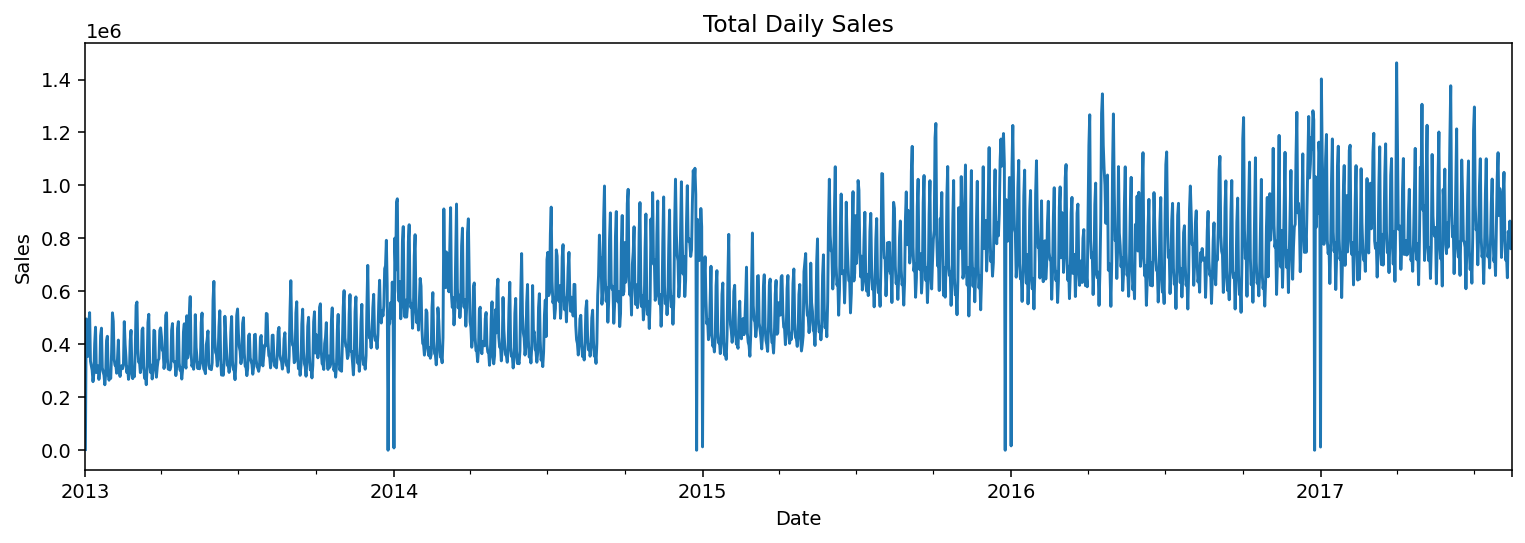

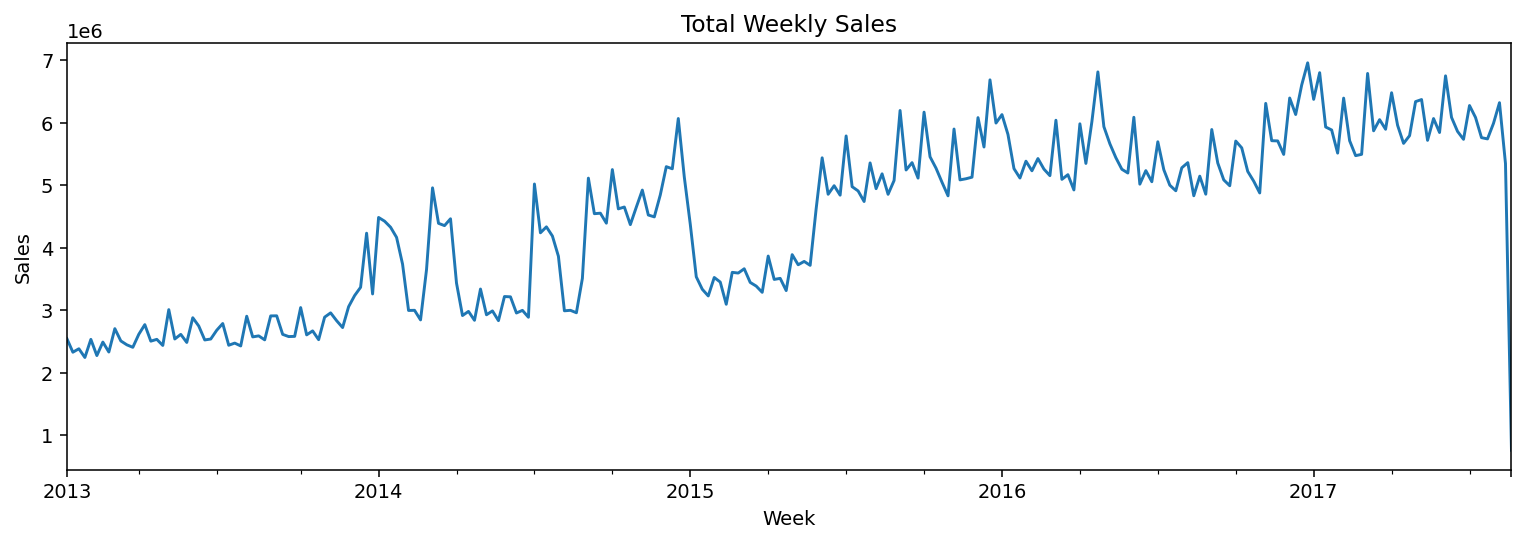

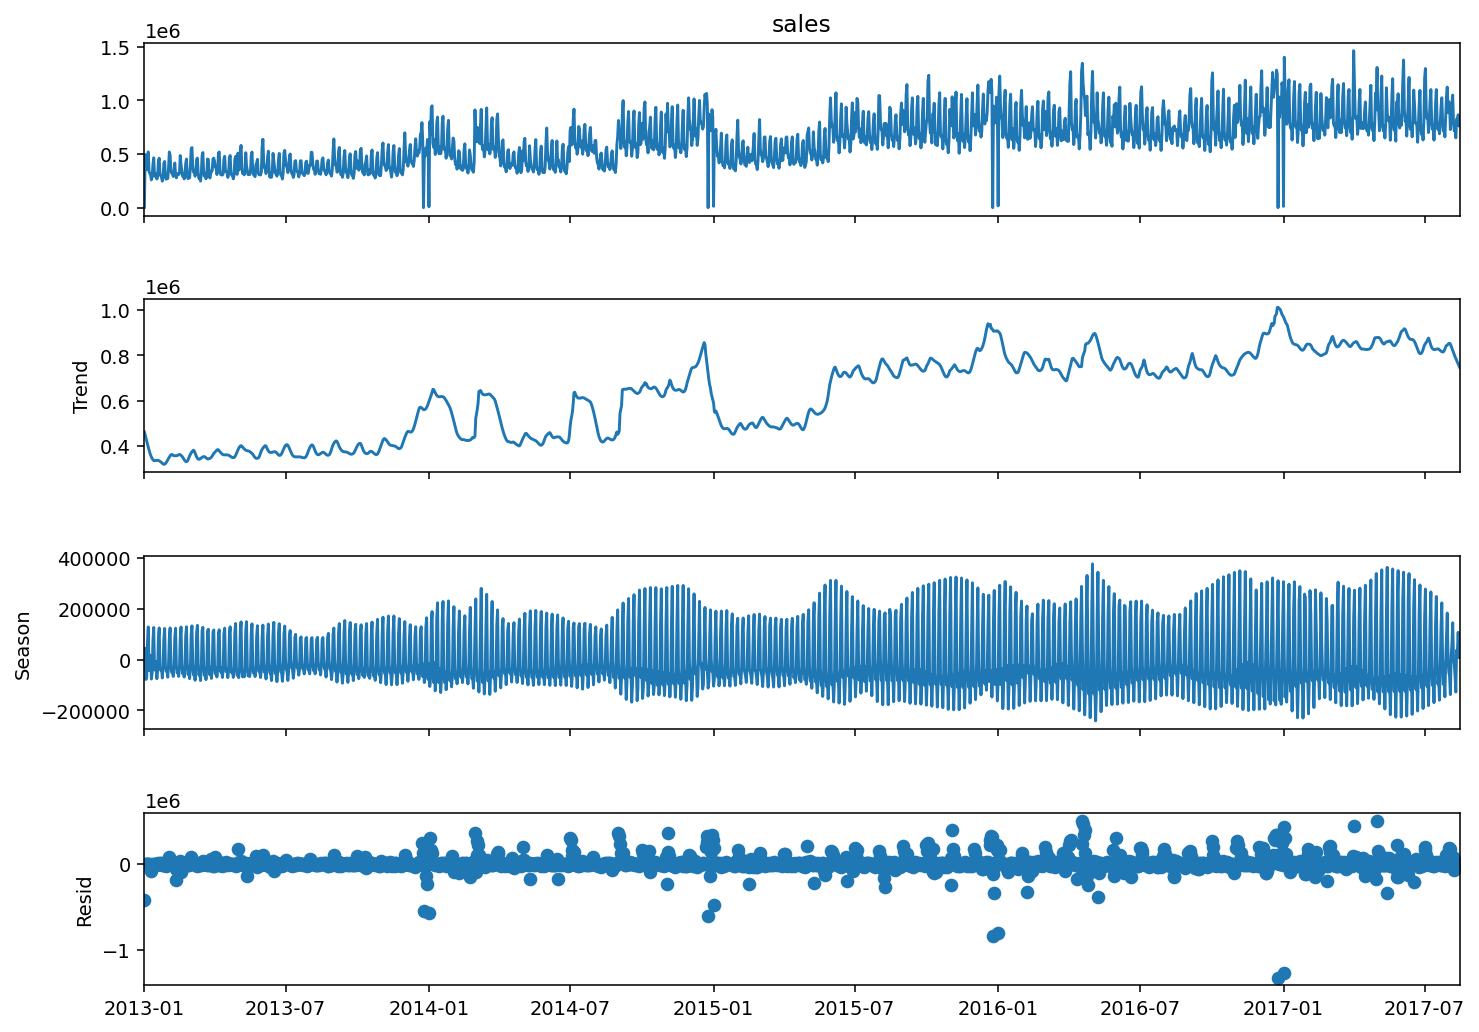

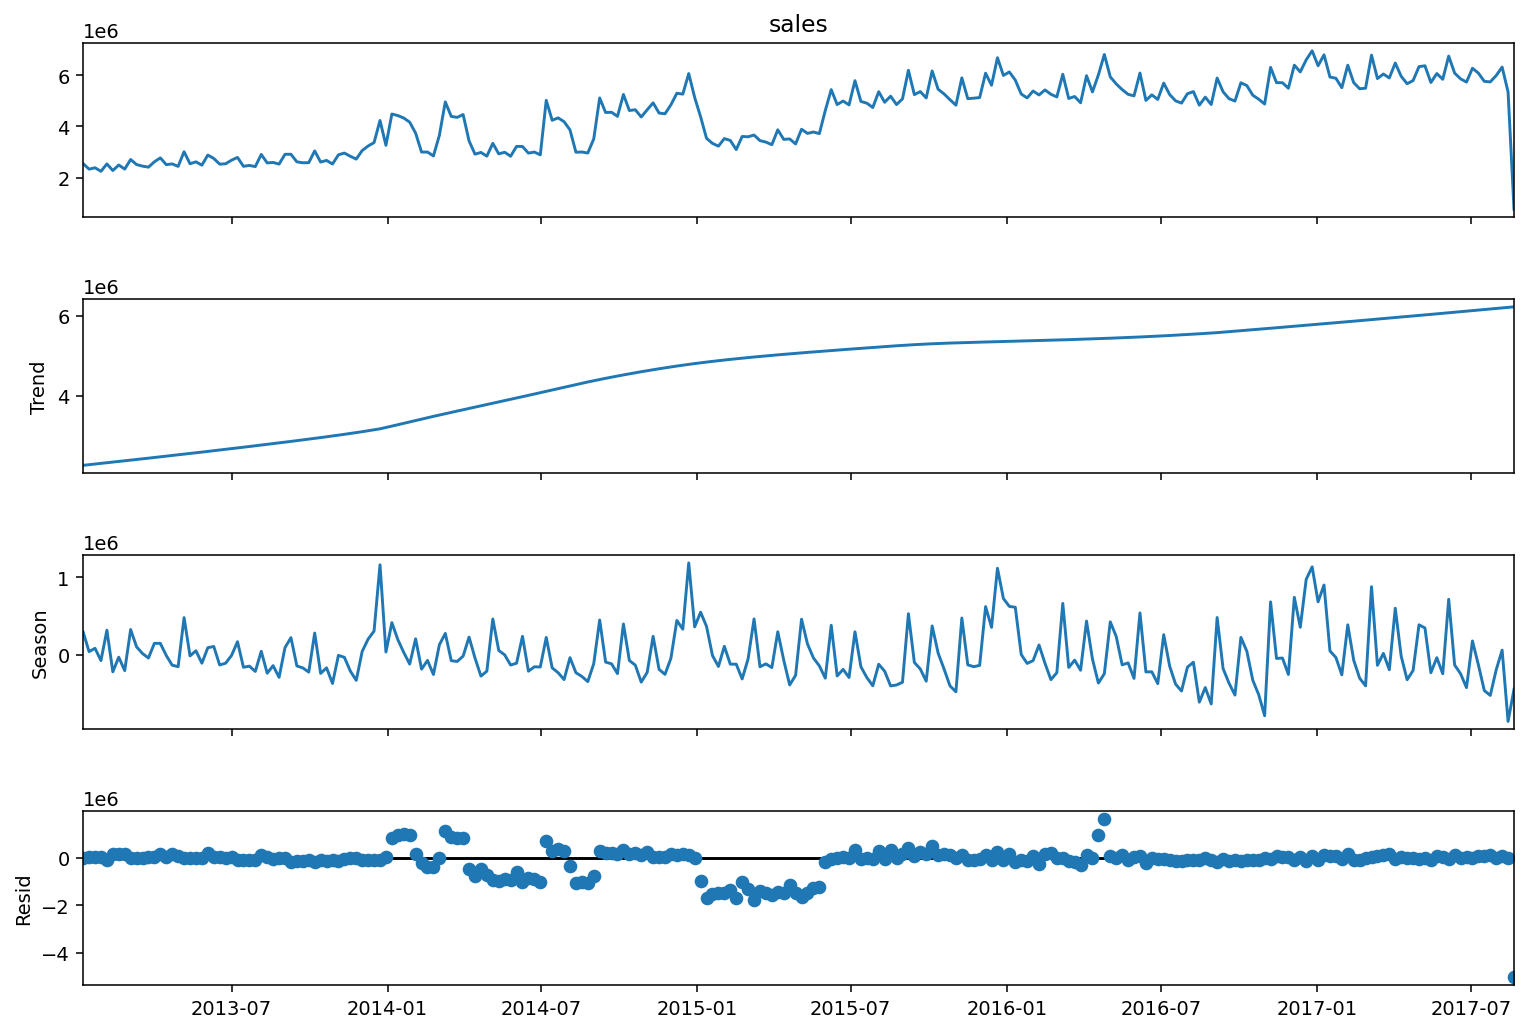

count    2.420000e+02
mean     4.436549e+06
std      1.343956e+06
min      7.626619e+05
25%      3.003618e+06
50%      4.845344e+06
75%      5.489619e+06
max      6.959313e+06
Name: sales, dtype: float64

In [7]:
daily_total = panel.groupby("date", observed=True)["sales"].sum().asfreq("D").fillna(0)
weekly_total = daily_total.resample("W-MON").sum()

fig, ax = plt.subplots(figsize=(11, 4))
daily_total.plot(ax=ax)
ax.set_title("Total Daily Sales")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
save_and_show(fig, FIGURE_DIR / "total_daily_sales.png")

fig, ax = plt.subplots(figsize=(11, 4))
weekly_total.plot(ax=ax)
ax.set_title("Total Weekly Sales")
ax.set_xlabel("Week")
ax.set_ylabel("Sales")
save_and_show(fig, FIGURE_DIR / "total_weekly_sales.png")

for name, values, period in [("daily_total", daily_total, 7), ("weekly_total", weekly_total, 52)]:
    decomposition = STL(values.astype(float), period=period, robust=True).fit()
    figure = decomposition.plot()
    figure.set_size_inches(12, 8)
    output_path = FIGURE_DIR / f"{name}_stl.png"
    figure.savefig(output_path, dpi=140, bbox_inches="tight")
    display_saved_image(output_path)
    plt.close(figure)

weekly_total.describe()

### ACF/PACF and Seasonal Lags

Daily lags inspect weekly repetition. Weekly lags inspect quarterly and annual behavior. Level-specific lag autocorrelations are also recorded.

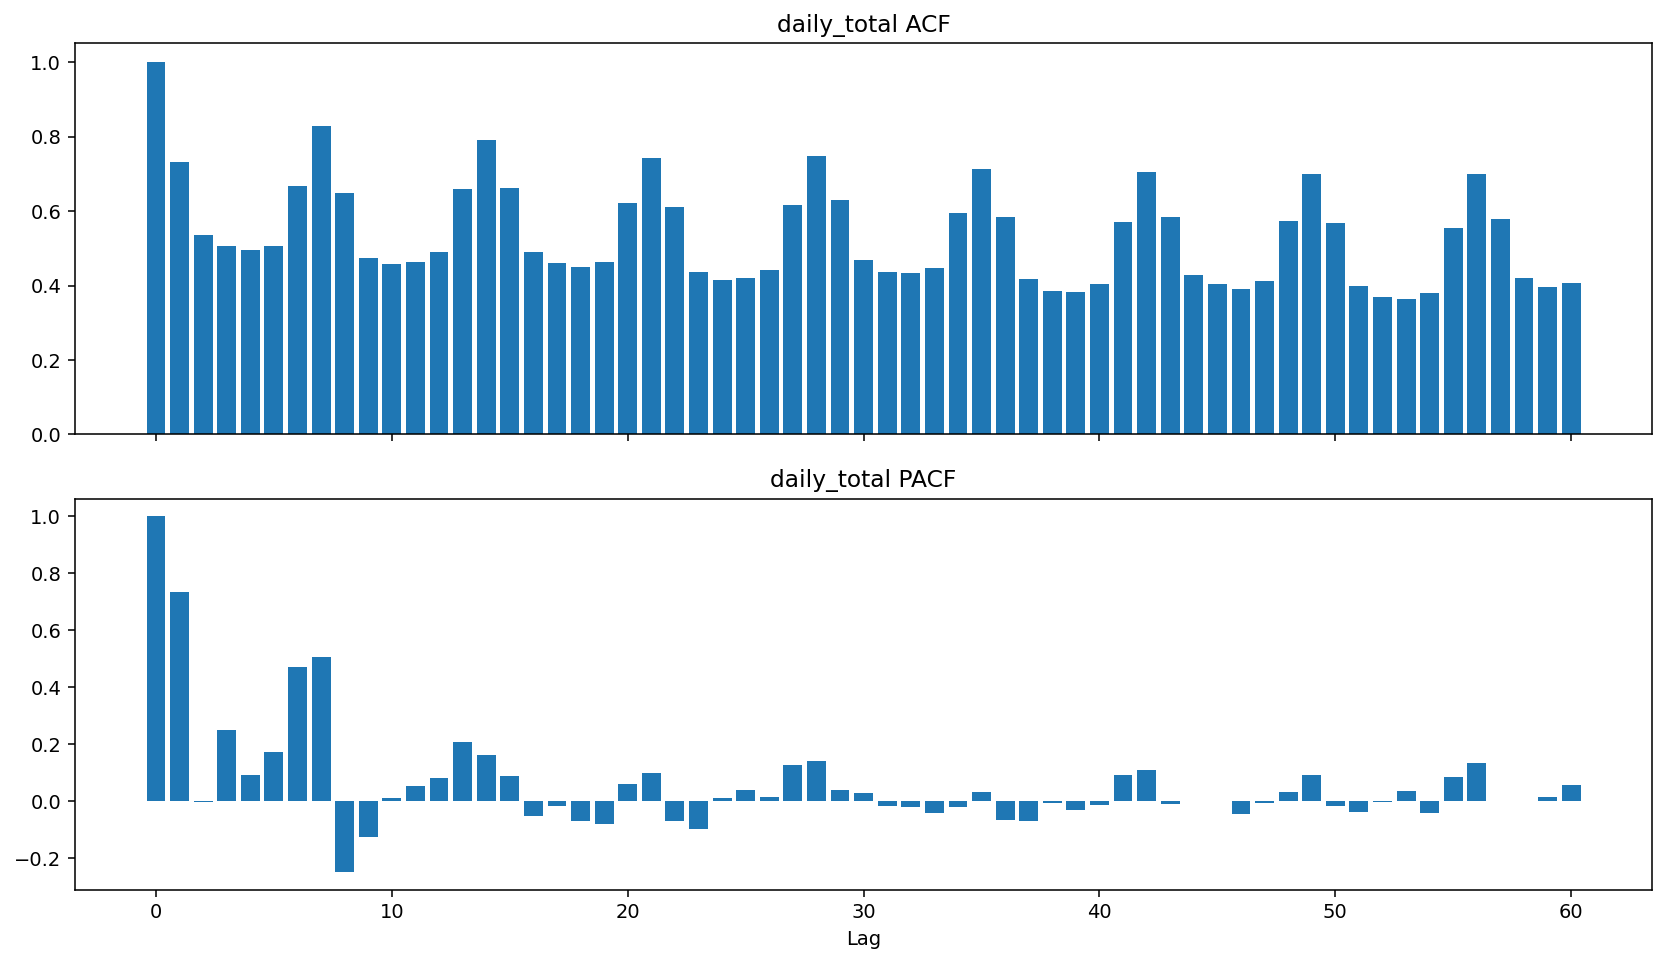

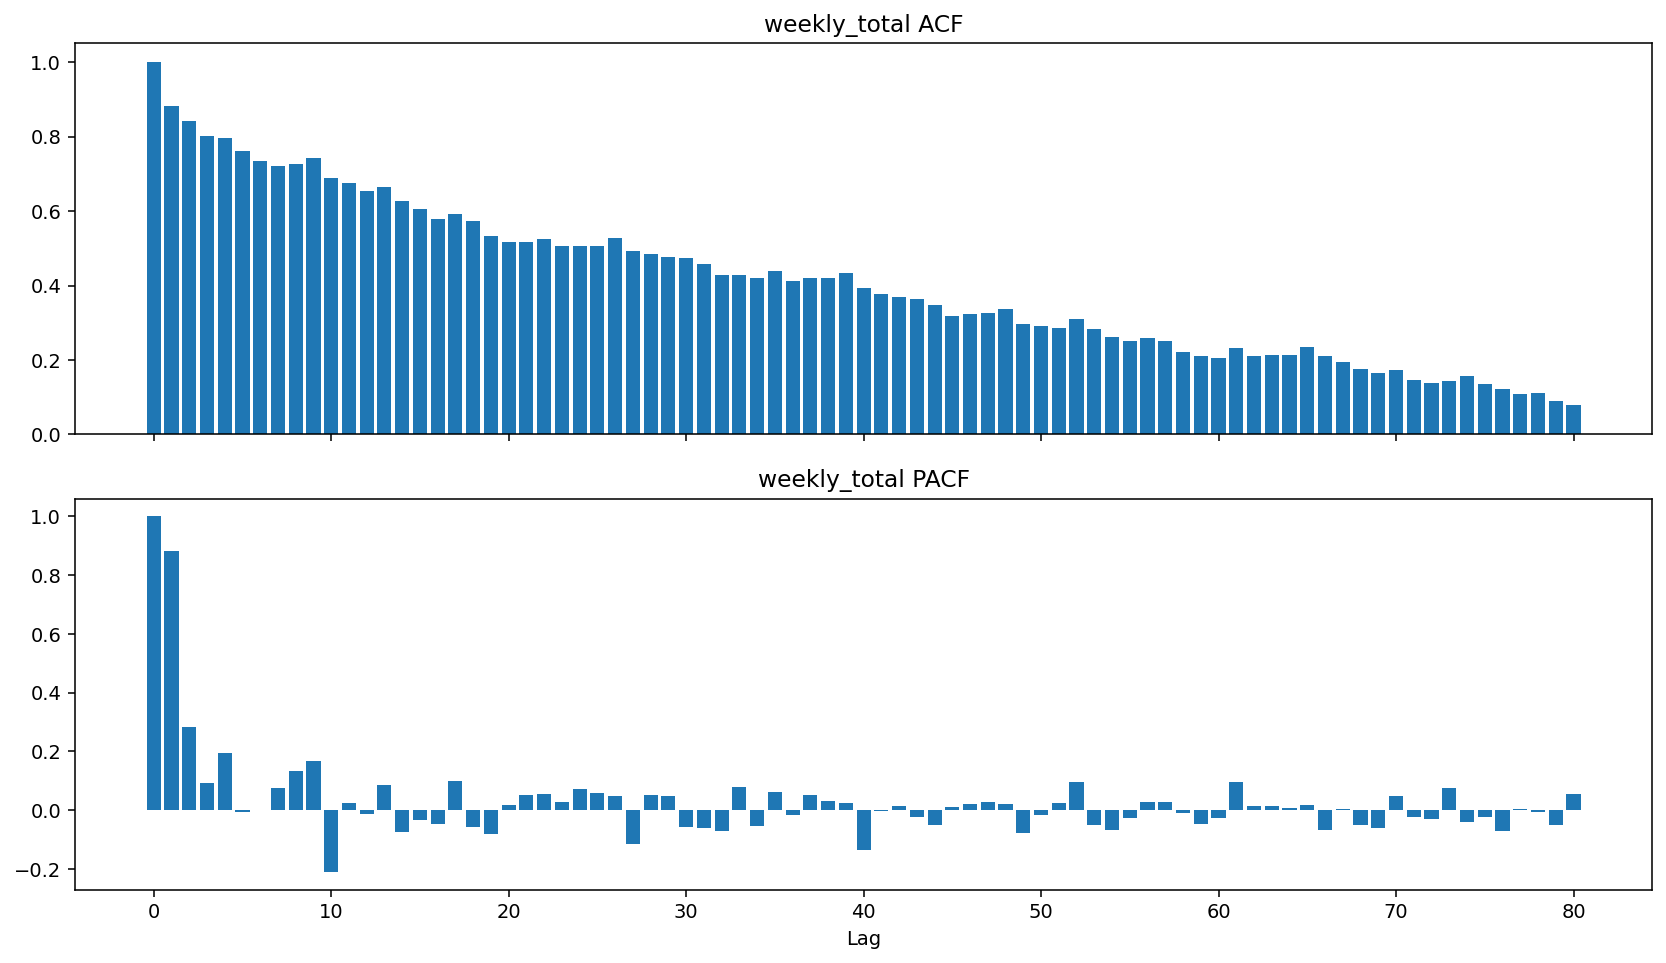

,series,kind,lag,value
1,daily_total,acf,1,0.732555
7,daily_total,acf,7,0.829415
14,daily_total,acf,14,0.791093
28,daily_total,acf,28,0.747827
52,daily_total,acf,52,0.369291
123,weekly_total,acf,1,0.882068
129,weekly_total,acf,7,0.720396
136,weekly_total,acf,14,0.627939
150,weekly_total,acf,28,0.484629
174,weekly_total,acf,52,0.311198


In [8]:
daily_acf = plot_acf_pacf("daily_total", daily_total, 60, FIGURE_DIR / "daily_total_acf_pacf.png")
weekly_acf = plot_acf_pacf("weekly_total", weekly_total, 80, FIGURE_DIR / "weekly_total_acf_pacf.png")
acf_pacf_values = pd.concat([daily_acf, weekly_acf], ignore_index=True)
acf_pacf_values.to_csv(TABLE_DIR / "acf_pacf_values.csv", index=False)
acf_pacf_values.loc[
    (acf_pacf_values["kind"] == "acf") & (acf_pacf_values["lag"].isin([1, 7, 14, 28, 52])),
    ["series", "kind", "lag", "value"],
]

In [9]:
seasonal_lag_rows = []
for keys, level in level_specs:
    daily = hierarchy_daily(joined, keys, level)
    for series_id, frame in daily.groupby("series_id", observed=True):
        values = frame.sort_values("date").set_index("date")["sales"].asfreq("D").fillna(0)
        seasonal_lag_rows.append(
            {
                "level": level,
                "series_id": series_id,
                "lag_7_autocorr": lag_autocorrelation(values, 7),
                "lag_14_autocorr": lag_autocorrelation(values, 14),
                "lag_28_autocorr": lag_autocorrelation(values, 28),
            }
        )
seasonal_lags = pd.DataFrame(seasonal_lag_rows)
seasonal_lags.to_csv(TABLE_DIR / "seasonal_lags_by_level_series.csv", index=False)
seasonal_lag_summary = (
    seasonal_lags.groupby("level", observed=True)[["lag_7_autocorr", "lag_14_autocorr", "lag_28_autocorr"]]
    .agg(["count", "mean", "median"])
)
seasonal_lag_summary.to_csv(TABLE_DIR / "seasonal_lags_by_level_summary.csv")
seasonal_lag_summary

lag_7_autocorr                     lag_14_autocorr            \
                      count      mean    median           count      mean   
level                                                                       
city                     22  0.713745  0.759170              22  0.660891   
cluster                  17  0.808701  0.800705              17  0.767240   
family                   33  0.739973  0.762056              33  0.659397   
state                    16  0.737275  0.768782              16  0.681524   
store                    54  0.695173  0.728426              54  0.649375   
store_family           1728  0.463793  0.464975            1728  0.409947   
total                     1  0.833246  0.833246               1  0.799722   

                       lag_28_autocorr                      
                median           count      mean    median  
level                                                       
city          0.697037              22  0.641001  0.640722  
cluster       0.762174              17  0.725126  0.718962  
family        0.703011              33  0.596460  0.634370  
state         0.704967              16  0.656101  0.676920  
store         0.687015              54  0.613435  0.640394  
store_family  0.400172            1727  0.365222  0.350639  
total         0.799722               1  0.765973  0.765973

### Stationarity

ADF and KPSS are run on representative high-volume series at each hierarchy level before and after first differencing.

In [10]:
stationarity_frames = []
for keys, level in level_specs:
    daily = hierarchy_daily(joined, keys, level)
    sample_limit = 1 if level == "total" else 5
    sample = stationarity_sample(daily, sample_limit)
    sample.insert(0, "level", level)
    stationarity_frames.append(sample)
stationarity_tests = pd.concat(stationarity_frames, ignore_index=True)
stationarity_tests.to_csv(TABLE_DIR / "stationarity_tests.csv", index=False)
stationarity_summary = stationarity_tests.assign(
    level_stationary_adf=stationarity_tests["adf_p"] < 0.05,
    level_stationary_kpss=stationarity_tests["kpss_p"] >= 0.05,
    diff_stationary_adf=stationarity_tests["diff_adf_p"] < 0.05,
    diff_stationary_kpss=stationarity_tests["diff_kpss_p"] >= 0.05,
).groupby("level", observed=True)[[
    "level_stationary_adf",
    "level_stationary_kpss",
    "diff_stationary_adf",
    "diff_stationary_kpss",
]].mean().reset_index()
stationarity_summary.to_csv(TABLE_DIR / "stationarity_summary_by_level.csv", index=False)
stationarity_summary

,level,level_stationary_adf,level_stationary_kpss,diff_stationary_adf,diff_stationary_kpss
0,city,0.2,0.0,1.0,1.0
1,cluster,0.2,0.0,1.0,1.0
2,family,0.6,0.0,1.0,1.0
3,state,0.2,0.0,1.0,1.0
4,store,0.6,0.0,1.0,1.0
5,store_family,1.0,0.0,1.0,1.0
6,total,0.0,0.0,1.0,1.0


### Seasonality Strength by Intermittency Segment

Lag-7 autocorrelation is measured per bottom series and summarized by intermittency segment.

In [11]:
segment_lookup = series_inventory[["store_nbr", "family", "intermittency_segment"]]
lag7_rows = []
for (store_nbr, family), frame in panel.groupby(["store_nbr", "family"], observed=True):
    values = frame.sort_values("date").set_index("date")["sales"].asfreq("D").fillna(0)
    lag7_rows.append({"store_nbr": store_nbr, "family": family, "lag7_autocorr": lag_autocorrelation(values, 7)})
lag7_by_series = pd.DataFrame(lag7_rows).merge(segment_lookup, on=["store_nbr", "family"], how="left")
lag7_summary = (
    lag7_by_series.groupby("intermittency_segment", observed=True)["lag7_autocorr"]
    .agg(["count", "mean", "median"])
    .reset_index()
)
lag7_by_series.to_csv(TABLE_DIR / "lag7_autocorr_by_series.csv", index=False)
lag7_summary.to_csv(TABLE_DIR / "weekly_seasonality_by_segment.csv", index=False)
lag7_summary

,intermittency_segment,count,mean,median
0,erratic,371,0.393492,0.376027
1,intermittent,226,0.218853,0.151309
2,lumpy,188,0.341651,0.345190
3,smooth,943,0.574503,0.605584


### Outliers and Closures

This catalogs dates with total-demand outliers and dates where many stores report zero demand.

In [12]:
rolling_median = daily_total.rolling(28, center=True, min_periods=14).median()
residual = daily_total - rolling_median
mad = (residual - residual.median()).abs().median()
robust_z = 0.6745 * (residual - residual.median()) / mad

total_outlier_dates = pd.DataFrame(
    {"date": daily_total.index, "sales": daily_total.values, "robust_z": robust_z.values}
).dropna()
total_outlier_dates = total_outlier_dates.loc[total_outlier_dates["robust_z"].abs() >= 6].sort_values(
    "robust_z", key=lambda column: column.abs(), ascending=False
)
total_outlier_dates.to_csv(TABLE_DIR / "total_outlier_dates.csv", index=False)

store_daily = joined.groupby(["store_nbr", "date"], observed=True, as_index=False)["sales"].sum()
store_level_zero_days = (
    store_daily.loc[store_daily["sales"] == 0]
    .groupby("date")
    .size()
    .sort_values(ascending=False)
    .head(30)
    .reset_index(name="stores_zero")
)
store_level_zero_days.to_csv(TABLE_DIR / "store_level_zero_days_top30.csv", index=False)

christmas_rows = daily_total.loc[daily_total.index.strftime("%m-%d") == "12-25"]
print("Christmas total rows after P0 reindex:")
print(christmas_rows)
print("Top store-level zero dates:")
store_level_zero_days.head(10)

Christmas total rows after P0 reindex:
date
2013-12-25    0.0
2014-12-25    0.0
2015-12-25    0.0
2016-12-25    0.0
Name: sales, dtype: float64
Top store-level zero dates:


,date,stores_zero
0,2016-12-25,53
1,2015-12-25,53
2,2017-01-01,52
3,2016-01-01,52
4,2014-12-25,48
5,2015-01-01,47
6,2013-12-25,47
7,2014-01-01,45
8,2016-09-22,2
9,2016-09-24,2


### Demand Distribution and Variance Profile

Bottom demand is checked for zero inflation, skew, and high outliers. Variance by hierarchy level shows how aggregation reduces noise.

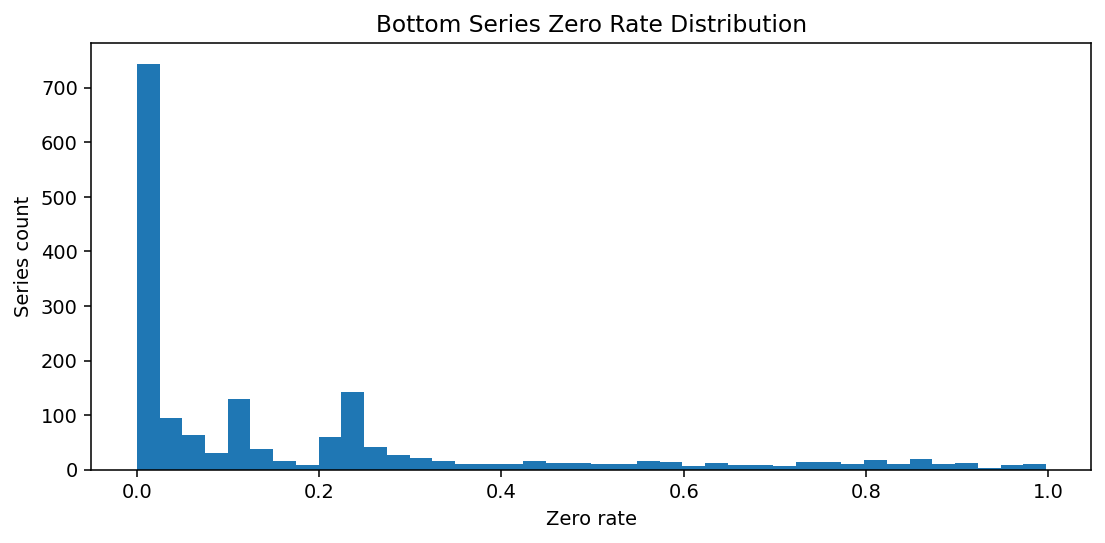

(                metric          value
 0     bottom_zero_rate       0.158638
 1    bottom_mean_sales     438.133015
 2  bottom_median_sales      32.000000
 3     bottom_p95_sales    2365.954400
 4     bottom_p99_sales    6077.620830
 5     bottom_max_sales  124717.000000,
           level  mean_variance  median_variance
 0         total   5.577938e+10     5.577938e+10
 1         state   1.224167e+09     3.578958e+07
 2          city   8.115843e+08     1.779904e+07
 3         store   3.497585e+07     1.810100e+07
 4       cluster   3.241146e+08     1.478644e+08
 5        family   3.769596e+08     5.086125e+05
 6  store_family   2.871189e+05     5.954443e+02)

In [13]:
demand_distribution = pd.DataFrame(
    {
        "metric": [
            "bottom_zero_rate",
            "bottom_mean_sales",
            "bottom_median_sales",
            "bottom_p95_sales",
            "bottom_p99_sales",
            "bottom_max_sales",
        ],
        "value": [
            float((panel["sales"] == 0).mean()),
            float(panel["sales"].mean()),
            float(panel["sales"].median()),
            float(panel["sales"].quantile(0.95)),
            float(panel["sales"].quantile(0.99)),
            float(panel["sales"].max()),
        ],
    }
)
demand_distribution.to_csv(TABLE_DIR / "demand_distribution_summary.csv", index=False)

variance_rows = []
for keys, level in level_specs:
    daily = hierarchy_daily(joined, keys, level)
    per_series = daily.groupby("series_id", observed=True)["sales"].var()
    variance_rows.append(
        {
            "level": level,
            "mean_variance": float(per_series.mean()),
            "median_variance": float(per_series.median()),
        }
    )
variance_profile = pd.DataFrame(variance_rows)
variance_profile.to_csv(TABLE_DIR / "variance_profile_by_level.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(series_inventory["zero_rate"], bins=40)
ax.set_title("Bottom Series Zero Rate Distribution")
ax.set_xlabel("Zero rate")
ax.set_ylabel("Series count")
save_and_show(fig, FIGURE_DIR / "bottom_zero_rate_distribution.png")

demand_distribution, variance_profile

### P1 Interim Findings and Open Questions for P2

**What the current P1 run produced**

- Active bottom series after P0: 1,729 store-family series.
- Post-launch history length: min 37 days, median 1,686 days, max 1,688 days.
- Bottom-level zero rate after P0 truncation: 15.86% across panel rows.
- Series inactive in the final 90 days: 31.
- Intermittency segments: 943 smooth, 371 erratic, 227 intermittent, 188 lumpy.
- Zero rate by hierarchy level supports the constitution's broad assignment: total/state/city/store/cluster are under 1%, family is 6.0%, and bottom store-family is 15.9% after truncation.
- Lag-7 autocorrelation is strongest for smooth series: median 0.606. Intermittent series have much weaker weekly structure: median 0.151.
- Stationarity tests indicate non-stationary levels for most aggregates and much stronger stationarity after first differencing.
- Closure/outlier catalog confirms Christmas rows are zero after P0 reindexing: 2013-12-25, 2014-12-25, 2015-12-25, 2016-12-25. New Year's Day also appears as a major low-demand closure/outlier.
- Demand remains strongly skewed at the bottom level: median daily sales 32, p95 2,365.952, p99 6,077.617, max 124,717.

**Artifacts written by the notebook run**

- Tables: `outputs/metrics/p1_ts_eda/`
- Figures: `outputs/figures/p1_ts_eda/`

**P1 exit criteria status**

- Every series assigned to an intermittency segment: done in `series_inventory.csv` and `intermittency_segments.csv`.
- Seasonal lags identified per level with evidence: done in `seasonal_lags_by_level_series.csv`, `seasonal_lags_by_level_summary.csv`, and ACF/PACF figures.
- Stationarity result recorded per level: done for high-volume samples at every level in `stationarity_tests.csv` and `stationarity_summary_by_level.csv`.
- Outlier and closure dates catalogued: done in `total_outlier_dates.csv` and `store_level_zero_days_top30.csv`.
- Grain decision: weekly grain remains supported by strong weekly structure, closure spikes, and the need to avoid quarter-ahead daily noise.
- Model-to-level assignment: broadly supported by the zero-rate profile and segment seasonality table.

**Open questions for P2**

- Which families and stores have the strongest promotion response, and is the response large enough to justify promo features?
- Do transferred holidays behave like normal days, and does the transfer row carry the effect?
- Does oil correlate with demand at any lag after aggregation, or is it mostly a weak macro regressor?
- Are transactions a useful leading signal, or mainly contemporaneous/collinear with sales?
- Do store type, cluster, city, or state explain demand shape enough to justify encodings?

## P2 · Supporting EDA

Not started. P2 begins only after P1 exit criteria are accepted.

## P3 · Feature Building

Not started. P3 begins only after P2 exit criteria are accepted.